# Network Anomaly Detection on UNSW-NB15: Random Forest vs XGBoost
Follows the paper's method: **combine the train + test files (~257k records)** and evaluate with **5-fold stratified cross-validation**.

Task: binary classification, 0 = normal, 1 = attack.

## 1. Imports

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import LabelEncoder, MinMaxScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.pipeline import make_pipeline
from sklearn.model_selection import StratifiedKFold, cross_validate, cross_val_predict
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
from xgboost import XGBClassifier

## 2. Load data and combine the two files

In [2]:
train = pd.read_csv("UNSW_NB15_training-set.csv", encoding="utf-8-sig")
test  = pd.read_csv("UNSW_NB15_testing-set.csv",  encoding="utf-8-sig")

df = pd.concat([train, test], ignore_index=True)
print("Combined shape:", df.shape)
print(df["label"].value_counts())

Combined shape: (257673, 45)
label
1    164673
0     93000
Name: count, dtype: int64


## 3. Preprocess (as in the paper)
Drop `id` and `attack_cat` (it would leak the answer), then label-encode `proto`, `service`, `state`.

In [3]:
y = df["label"]
X = df.drop(columns=["id", "attack_cat", "label"])

for col in ["proto", "service", "state"]:
    X[col] = LabelEncoder().fit_transform(X[col])

print("Features:", X.shape[1])

Features: 42


## 4. Models
Settings from the paper: Random Forest with 100 trees; XGBoost with defaults and `logloss`.

Min-Max scaling is placed inside a pipeline, so it is fitted only on the training part of each fold.

In [4]:
rf  = make_pipeline(MinMaxScaler(),
                    RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1))
xgb = make_pipeline(MinMaxScaler(),
                    XGBClassifier(eval_metric="logloss", random_state=42, n_jobs=-1))

## 5. 5-fold stratified cross-validation

In [5]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
scoring = {"Accuracy": "accuracy", "Precision": "precision",
           "Recall": "recall", "F1-Score": "f1", "AUC": "roc_auc"}

rows = {}
for name, model in [("Random Forest", rf), ("XGBoost", xgb)]:
    scores = cross_validate(model, X, y, cv=cv, scoring=scoring)
    rows[name] = {m: f"{scores['test_'+m].mean():.3f} ± {scores['test_'+m].std():.3f}"
                  for m in scoring}
    print(name, "done")

results = pd.DataFrame(rows).T
results

Random Forest done
XGBoost done


,Accuracy,Precision,Recall,F1-Score,AUC
Random Forest,0.951 ± 0.001,0.964 ± 0.001,0.960 ± 0.001,0.962 ± 0.000,0.992 ± 0.000
XGBoost,0.948 ± 0.001,0.966 ± 0.001,0.953 ± 0.001,0.959 ± 0.001,0.992 ± 0.000


## 7. Chart

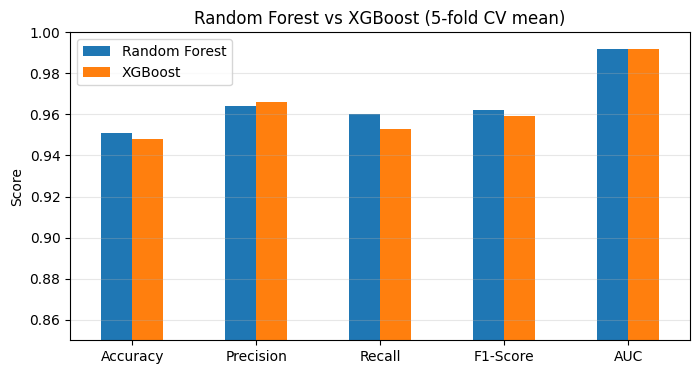

In [6]:
means = results.apply(lambda col: col.str.split(" ").str[0].astype(float))
means.T.plot(kind="bar", figsize=(8, 4))
plt.title("Random Forest vs XGBoost (5-fold CV mean)")
plt.ylabel("Score")
plt.ylim(0.85, 1.0)
plt.xticks(rotation=0)
plt.grid(axis="y", alpha=0.3)
plt.show()